# Modeling

CRISP-DM Phase 4 for **Predicting Fork-to-PR Conversion in Open-Source Repositories**.

In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
%matplotlib inline

## 1) Select Modeling Technique

Two target formulations are used to match project success criteria from Stage 1:

- **Classification target**: `has_conversion` (binary, whether repository-season had at least one converted fork).
- **Regression target**: `fork_conversion_rate` (continuous conversion intensity).

Model candidates:
- Baseline predictors
- Logistic Regression / Linear Regression for transparent baselines.
- Random Forest and Extra Trees for non-linear activity interactions.
- Gradient Boosting and Histogram Gradient Boosting for stronger tabular performance on skewed activity data.


## 2) Generate Test Design

- Main dataset: `modeling_dataset_obs30d.parquet`, following the Data Preparation sensitivity recommendation.
- Sensitivity dataset: `modeling_dataset_obs90d.parquet`, evaluated with the same feature contract and ranking metrics.
- Hold-out strategy: random train/test split (80/20, `random_state=42`).
- Feature contract: use Data Preparation activity features (`season`, `log1p_*`, raw counts, winsorized counts, `activity_strength`, and `stratum_activity_quintile`). Label-derived counters such as `n_forks`, `n_converted_forks`, `n_pr_events`, and `stratum_fork_quintile` are not predictors.
- Primary metrics:
  - Classification: Accuracy, Macro-F1, Precision, ROC-AUC, Precision@10%.
  - Regression: MAE, R2.
- Baselines:
  - Classification: predict majority class.
  - Regression: predict train mean conversion rate.


In [3]:
DATA_DIRS = [Path("data"), Path("src/data"), Path("../src/data")]
MAIN_OBSERVATION_WINDOW_DAYS = 30
SENSITIVITY_WINDOWS_DAYS = (30, 90)


def _looks_like_git_lfs_pointer(path: Path) -> bool:
    """Detect tiny text pointer files committed by Git LFS instead of real binary data."""
    try:
        head = path.read_bytes()[:64]
    except Exception:
        return False
    return head.startswith(b"version https://git-lfs.github.com/spec/v1")


def _candidate_paths(basename):
    candidates = []
    for d in DATA_DIRS:
        candidates.append(d / f"{basename}.parquet")
        candidates.append(d / f"{basename}.csv")
    return candidates


def load_dataset(basename):
    load_errors = []
    for p in _candidate_paths(basename):
        if not p.exists():
            continue
        try:
            if p.suffix == ".parquet":
                if _looks_like_git_lfs_pointer(p):
                    raise RuntimeError("Git LFS pointer file detected, not real parquet data")
                return pd.read_parquet(p), p
            return pd.read_csv(p), p
        except Exception as exc:
            load_errors.append(f"{p}: {exc}")

    err_text = "\n".join(load_errors) if load_errors else "No candidate files found"
    raise RuntimeError(
        f"Could not load {basename}.\n"
        "Reason(s):\n"
        f"{err_text}\n\n"
        "If files are Git LFS pointers, fetch real data with `git lfs pull` "
        "or re-export the datasets from DataPreparation.ipynb."
    )


datasets_by_window = {}
sources_by_window = {}
for window in SENSITIVITY_WINDOWS_DAYS:
    datasets_by_window[window], sources_by_window[window] = load_dataset(f"modeling_dataset_obs{window}d")

# Backward-compatible fallback for older exports.
try:
    df = datasets_by_window[MAIN_OBSERVATION_WINDOW_DAYS].copy()
    source_used = sources_by_window[MAIN_OBSERVATION_WINDOW_DAYS]
except KeyError:
    df, source_used = load_dataset("modeling_dataset")

print(f"Loaded main dataset: {source_used}")
print("Shape:", df.shape)
print("Sensitivity sources:")
for window, path in sources_by_window.items():
    print(f"  {window}d: {path} {datasets_by_window[window].shape}")

df.head(3)

Loaded main dataset: data/modeling_dataset_obs30d.parquet
Shape: (100000, 32)
Sensitivity sources:
  30d: data/modeling_dataset_obs30d.parquet (100000, 32)
  90d: data/modeling_dataset_obs90d.parquet (100000, 32)


,repo_name,repo_id,season,log1p_issue_comments,log1p_issue_comments_winsor,log1p_issues,log1p_issues_winsor,log1p_pushes,log1p_pushes_winsor,log1p_releases,log1p_releases_winsor,log1p_watches,log1p_watches_winsor,activity_strength,stratum_activity_quintile,stratum_fork_quintile,observation_window_days,n_forks,n_converted_forks,fork_conversion_rate,n_pr_events,has_conversion,watches,pushes,issues,issue_comments,releases,watches_winsor,pushes_winsor,issues_winsor,issue_comments_winsor,releases_winsor
0,AutomationPanda/awesome-web-testing-playwright,3002,winter_spring,0.693147,0.693147,0.693147,0.693147,0.000000,0.000000,0.0,0.0,3.178054,3.178054,4.564348,1,1,30,8,0,0.0,0,0,23,0,1,1,0,23.0,0.0,1.0,1.0,0.0
1,Neamar/KISS,16186,summer_autumn,4.143135,4.143135,3.828641,3.828641,3.135494,3.135494,0.0,0.0,4.007333,4.007333,15.114604,4,2,30,10,3,0.3,35,1,54,22,45,62,0,54.0,22.0,45.0,62.0,0.0
2,magnific0/wondershaper,57159,winter_spring,2.302585,2.302585,1.098612,1.098612,0.000000,0.000000,0.0,0.0,3.401197,3.401197,6.802395,2,0,30,6,0,0.0,0,0,29,0,2,9,0,29.0,0.0,2.0,9.0,0.0


In [4]:
ACTIVITY_COUNT_COLS = ["watches", "pushes", "issues", "issue_comments", "releases"]
LABEL_DERIVED_EXCLUSIONS = [
    "observation_window_days",
    "n_forks",
    "n_converted_forks",
    "fork_conversion_rate",
    "n_pr_events",
    "has_conversion",
    "stratum_fork_quintile",
]


def selected_activity_features(frame):
    identifier_features = ["season"]
    log_features = [c for c in frame.columns if c.startswith("log1p_")]
    raw_features = [c for c in ACTIVITY_COUNT_COLS if c in frame.columns]
    winsor_features = [f"{c}_winsor" for c in ACTIVITY_COUNT_COLS if f"{c}_winsor" in frame.columns]
    helper_features = [c for c in ["activity_strength", "stratum_activity_quintile"] if c in frame.columns]

    ordered = identifier_features + helper_features + log_features + raw_features + winsor_features
    return [c for c in dict.fromkeys(ordered) if c not in LABEL_DERIVED_EXCLUSIONS]


def make_xy(frame):
    y_cls_local = frame["has_conversion"].astype(int)
    y_reg_local = frame["fork_conversion_rate"].astype(float)

    candidate_features_local = selected_activity_features(frame)
    missing = [c for c in ["season"] if c not in frame.columns]
    if missing:
        raise ValueError(f"Required selected features are missing: {missing}")

    X_local = frame[candidate_features_local].copy()
    cat_cols_local = [
        c
        for c in X_local.columns
        if pd.api.types.is_object_dtype(X_local[c])
        or pd.api.types.is_string_dtype(X_local[c])
        or pd.api.types.is_categorical_dtype(X_local[c])
        or pd.api.types.is_bool_dtype(X_local[c])
    ]
    num_cols_local = [c for c in X_local.columns if c not in cat_cols_local]
    return X_local, y_cls_local, y_reg_local, candidate_features_local, cat_cols_local, num_cols_local


X, y_cls, y_reg, candidate_features, cat_cols, num_cols = make_xy(df)

print("Feature columns:", len(candidate_features))
print("Selected features:", candidate_features)
print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))
print("Excluded label-derived columns:", [c for c in LABEL_DERIVED_EXCLUSIONS if c in df.columns])
print("Class balance (has_conversion):")
display(y_cls.value_counts(normalize=True).rename("share"))

Feature columns: 23
Selected features: ['season', 'activity_strength', 'stratum_activity_quintile', 'log1p_issue_comments', 'log1p_issue_comments_winsor', 'log1p_issues', 'log1p_issues_winsor', 'log1p_pushes', 'log1p_pushes_winsor', 'log1p_releases', 'log1p_releases_winsor', 'log1p_watches', 'log1p_watches_winsor', 'watches', 'pushes', 'issues', 'issue_comments', 'releases', 'watches_winsor', 'pushes_winsor', 'issues_winsor', 'issue_comments_winsor', 'releases_winsor']
Categorical: ['season']
Numeric count: 22
Excluded label-derived columns: ['observation_window_days', 'n_forks', 'n_converted_forks', 'fork_conversion_rate', 'n_pr_events', 'has_conversion', 'stratum_fork_quintile']
Class balance (has_conversion):


has_conversion
0    0.52758
1    0.47242
Name: share, dtype: float64

## 3) Build Model

In [5]:
X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocess(num_cols_local, cat_cols_local):
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_local),
            (
                "cat",
                Pipeline([
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    ("oh", make_one_hot_encoder()),
                ]),
                cat_cols_local,
            ),
        ],
        remainder="drop",
    )


preprocess = make_preprocess(num_cols, cat_cols)


def precision_at_fraction(y_true, scores, fraction=0.10):
    y_arr = np.asarray(y_true)
    if scores is None or len(y_arr) == 0:
        return np.nan
    k = max(1, int(np.ceil(fraction * len(y_arr))))
    order = np.argsort(np.asarray(scores))[::-1]
    return float(y_arr[order][:k].mean())


def ndcg_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    y_sorted = np.asarray(y_true)[order][:k]
    gains = (2 ** y_sorted - 1) / np.log2(np.arange(2, k + 2))
    dcg = gains.sum()
    ideal = np.sort(np.asarray(y_true))[::-1][:k]
    ideal_gains = (2 ** ideal - 1) / np.log2(np.arange(2, k + 2))
    idcg = ideal_gains.sum()
    return float(dcg / idcg) if idcg > 0 else np.nan


def make_model_specs(preprocess_local):
    clf_models_local = {
        "logistic_regression": Pipeline([
            ("prep", preprocess_local),
            ("model", LogisticRegression(max_iter=1200, class_weight="balanced", n_jobs=None)),
        ]),
        "random_forest_clf": Pipeline([
            ("prep", preprocess_local),
            ("model", RandomForestClassifier(
                n_estimators=180,
                max_depth=16,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced_subsample",
            )),
        ]),
        "extra_trees_clf": Pipeline([
            ("prep", preprocess_local),
            ("model", ExtraTreesClassifier(
                n_estimators=160,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            )),
        ]),
        "gradient_boosting_clf": Pipeline([
            ("prep", preprocess_local),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]),
        "hist_gradient_boosting_clf": Pipeline([
            ("prep", preprocess_local),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.06,
                max_iter=180,
                max_leaf_nodes=31,
                l2_regularization=0.01,
                random_state=42,
            )),
        ]),
    }

    reg_models_local = {
        "linear_regression": Pipeline([("prep", preprocess_local), ("model", LinearRegression())]),
        "random_forest_reg": Pipeline([
            ("prep", preprocess_local),
            ("model", RandomForestRegressor(
                n_estimators=180,
                max_depth=18,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "extra_trees_reg": Pipeline([
            ("prep", preprocess_local),
            ("model", ExtraTreesRegressor(
                n_estimators=160,
                max_depth=None,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "hist_gradient_boosting_reg": Pipeline([
            ("prep", preprocess_local),
            ("model", HistGradientBoostingRegressor(
                learning_rate=0.06,
                max_iter=180,
                max_leaf_nodes=31,
                l2_regularization=0.01,
                random_state=42,
            )),
        ]),
    }
    return clf_models_local, reg_models_local


clf_models, reg_models = make_model_specs(preprocess)
print("Model specifications prepared. Hyperparameter tuning runs next, before final evaluation.")

Model specifications prepared. Hyperparameter tuning runs next, before final evaluation.


## 4) Hyperparameter Tuning

Compact `RandomizedSearchCV` runs before final model assessment. The search is intentionally small so the notebook remains reproducible on the 100k-row sample while still checking whether tuned Random Forest variants improve over the default candidates.

In [6]:
rf_clf_search = RandomizedSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced_subsample")),
    ]),
    param_distributions={
        "model__n_estimators": [80, 150],
        "model__max_depth": [8, 14, None],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.6],
    },
    n_iter=3,
    scoring="f1_macro",
    cv=2,
    random_state=42,
    n_jobs=-1,
)
rf_clf_search.fit(X_train, y_cls_train)

rf_reg_search = RandomizedSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    param_distributions={
        "model__n_estimators": [80, 150],
        "model__max_depth": [8, 16, None],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.6],
    },
    n_iter=3,
    scoring="neg_mean_absolute_error",
    cv=2,
    random_state=42,
    n_jobs=-1,
)
rf_reg_search.fit(X_train, y_reg_train)

clf_models["random_forest_clf_tuned"] = rf_clf_search.best_estimator_
reg_models["random_forest_reg_tuned"] = rf_reg_search.best_estimator_

tuning_results = pd.DataFrame([
    {
        "track": "classification",
        "model": "random_forest_clf_tuned",
        "cv_score": rf_clf_search.best_score_,
        "best_params": str(rf_clf_search.best_params_),
    },
    {
        "track": "regression",
        "model": "random_forest_reg_tuned",
        "cv_score": rf_reg_search.best_score_,
        "best_params": str(rf_reg_search.best_params_),
    },
])
display(tuning_results)

,track,model,cv_score,best_params
0,classification,random_forest_clf_tuned,0.771491,"{'model__n_estimators': 150, 'model__min_sampl..."
1,regression,random_forest_reg_tuned,-0.102998,"{'model__n_estimators': 150, 'model__min_sampl..."


## 5) Assess Model

The assessment compares tuned and untuned candidates against the stage success criteria:

- **Classification**: macro-F1 should exceed naive baseline; precision should be meaningful under class imbalance; Precision@10% should show whether the top-ranked decile is useful for prioritization.
- **Regression**: MAE should be lower than mean baseline and R2 should be positive on test data.

,model,accuracy,macro_f1,precision,precision_at_10pct,roc_auc
5,hist_gradient_boosting_clf,0.78625,0.785039,0.785770,0.9475,0.861124
4,gradient_boosting_clf,0.78345,0.782422,0.778795,0.9490,0.860519
6,random_forest_clf_tuned,0.78095,0.780232,0.769263,0.9425,0.855246
2,random_forest_clf,0.77955,0.778858,0.767094,0.9415,0.853212
1,logistic_regression,0.77635,0.774815,0.779463,0.9305,0.846733
3,extra_trees_clf,0.77180,0.771147,0.757486,0.9395,0.846862
0,baseline_majority,0.52760,0.345378,0.000000,0.4724,NaN


,model,mae,r2
4,hist_gradient_boosting_reg,0.101106,0.433337
5,random_forest_reg_tuned,0.101559,0.417361
2,random_forest_reg,0.102298,0.406545
3,extra_trees_reg,0.103639,0.381158
1,linear_regression,0.114480,0.352856
0,baseline_mean,0.155112,-0.000070


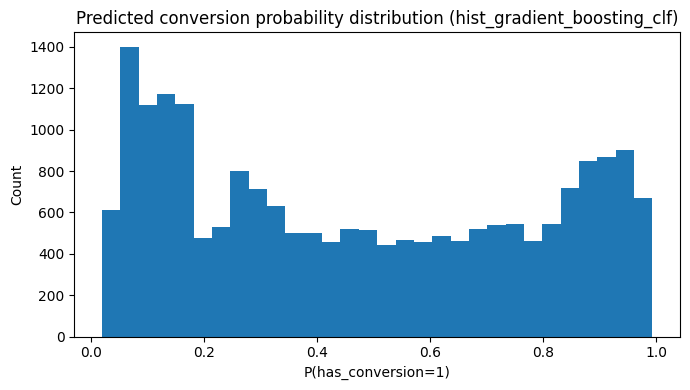

Best classification model: hist_gradient_boosting_clf
Best regression model: hist_gradient_boosting_reg


In [7]:
ARTIFACT_DIR = Path("../report/images")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def clip_rate(pred):
    """Conversion rate is bounded by construction, so evaluation should respect [0, 1]."""
    return np.clip(np.asarray(pred, dtype=float), 0.0, 1.0)


def evaluate_models(X_train_local, X_test_local, y_cls_train_local, y_cls_test_local, y_reg_train_local, y_reg_test_local, clf_models_local, reg_models_local):
    majority_class = int(y_cls_train_local.mode()[0])
    baseline_cls_pred = np.full_like(y_cls_test_local, fill_value=majority_class)

    cls_results_local = []
    for name, model in clf_models_local.items():
        model.fit(X_train_local, y_cls_train_local)
        pred = model.predict(X_test_local)
        if hasattr(model.named_steps["model"], "predict_proba"):
            proba = model.predict_proba(X_test_local)[:, 1]
            auc = roc_auc_score(y_cls_test_local, proba)
        else:
            proba = None
            auc = np.nan
        cls_results_local.append({
            "model": name,
            "accuracy": accuracy_score(y_cls_test_local, pred),
            "macro_f1": f1_score(y_cls_test_local, pred, average="macro"),
            "precision": precision_score(y_cls_test_local, pred, zero_division=0),
            "precision_at_10pct": precision_at_fraction(y_cls_test_local, proba, fraction=0.10),
            "roc_auc": auc,
        })

    baseline_cls = {
        "model": "baseline_majority",
        "accuracy": accuracy_score(y_cls_test_local, baseline_cls_pred),
        "macro_f1": f1_score(y_cls_test_local, baseline_cls_pred, average="macro"),
        "precision": precision_score(y_cls_test_local, baseline_cls_pred, zero_division=0),
        "precision_at_10pct": float(y_cls_test_local.mean()),
        "roc_auc": np.nan,
    }
    cls_table_local = pd.DataFrame([baseline_cls] + cls_results_local).sort_values("macro_f1", ascending=False)

    baseline_mean = float(y_reg_train_local.mean())
    baseline_reg_pred = clip_rate(np.full_like(y_reg_test_local, baseline_mean, dtype=float))

    reg_results_local = []
    for name, model in reg_models_local.items():
        model.fit(X_train_local, y_reg_train_local)
        pred = clip_rate(model.predict(X_test_local))
        reg_results_local.append({
            "model": name,
            "mae": mean_absolute_error(y_reg_test_local, pred),
            "r2": r2_score(y_reg_test_local, pred),
        })

    baseline_reg = {
        "model": "baseline_mean",
        "mae": mean_absolute_error(y_reg_test_local, baseline_reg_pred),
        "r2": r2_score(y_reg_test_local, baseline_reg_pred),
    }
    reg_table_local = pd.DataFrame([baseline_reg] + reg_results_local).sort_values("mae")
    return cls_table_local, reg_table_local


cls_table, reg_table = evaluate_models(
    X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test, clf_models, reg_models
)
display(cls_table)
display(reg_table)

best_cls_name = cls_table.iloc[0]["model"]
best_reg_name = reg_table.iloc[0]["model"]
best_cls_model = clf_models[best_cls_name]
best_reg_model = reg_models[best_reg_name]

if best_cls_name != "baseline_majority" and hasattr(best_cls_model.named_steps["model"], "predict_proba"):
    best_cls_model.fit(X_train, y_cls_train)
    p = best_cls_model.predict_proba(X_test)[:, 1]
    plt.figure(figsize=(7, 4))
    plt.hist(p, bins=30)
    plt.title(f"Predicted conversion probability distribution ({best_cls_name})")
    plt.xlabel("P(has_conversion=1)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

print("Best classification model:", best_cls_name)
print("Best regression model:", best_reg_name)

## 6) Ranking Quality

Repository-seasons are ranked by predicted conversion probability. The validation report includes Precision@10%, lift over the base conversion rate, and NDCG@10%.

,metric,value
0,precision_at_10pct,0.947500
1,base_rate,0.472400
2,lift_at_10pct,2.005715
3,ndcg_at_10pct,0.951949


,decile,samples,positives,precision,lift_vs_base
0,D1,2000,1895,0.9475,2.005715
1,D2,2000,1749,0.8745,1.851185
2,D3,2000,1535,0.7675,1.624682
3,D4,2000,1334,0.6670,1.411939
4,D5,2000,1049,0.5245,1.110288
5,D6,2000,716,0.3580,0.757832
6,D7,2000,512,0.2560,0.541914
7,D8,2000,334,0.1670,0.353514
8,D9,2000,223,0.1115,0.236029
9,D10,2000,101,0.0505,0.106901


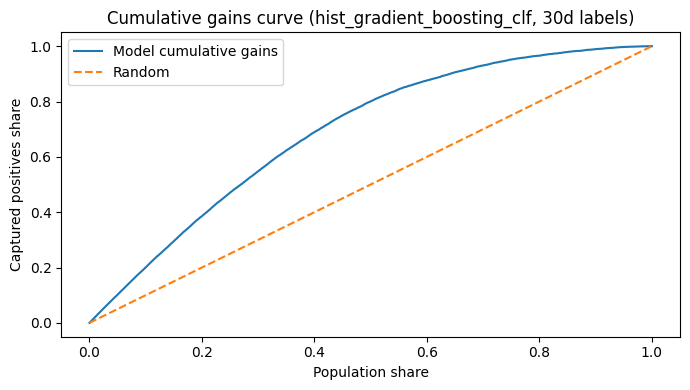

In [8]:
if best_cls_name != "baseline_majority" and hasattr(best_cls_model.named_steps["model"], "predict_proba"):
    best_cls_model.fit(X_train, y_cls_train)
    p_test = best_cls_model.predict_proba(X_test)[:, 1]
    y_true = y_cls_test.values

    n = len(y_true)
    k = max(1, int(np.ceil(0.10 * n)))
    order = np.argsort(p_test)[::-1]
    y_top = y_true[order][:k]

    precision_at_10 = float(y_top.mean())
    base_rate = float(y_true.mean())
    lift_at_10 = precision_at_10 / base_rate if base_rate > 0 else np.nan
    ndcg_10 = ndcg_at_k(y_true, p_test, k)

    ranking_summary = pd.DataFrame({
        "metric": ["precision_at_10pct", "base_rate", "lift_at_10pct", "ndcg_at_10pct"],
        "value": [precision_at_10, base_rate, lift_at_10, ndcg_10],
    })
    display(ranking_summary)

    rank_df = pd.DataFrame({"y": y_true, "score": p_test}).sort_values("score", ascending=False).reset_index(drop=True)
    rank_df["decile"] = pd.qcut(rank_df.index + 1, 10, labels=[f"D{i}" for i in range(1, 11)])
    lift_table = (
        rank_df.groupby("decile", observed=False)
        .agg(samples=("y", "size"), positives=("y", "sum"), precision=("y", "mean"))
        .reset_index()
    )
    lift_table["lift_vs_base"] = lift_table["precision"] / base_rate
    display(lift_table)

    cum_pos = np.cumsum(rank_df["y"].values)
    population_share = np.arange(1, n + 1) / n
    captured_share = cum_pos / cum_pos[-1] if cum_pos[-1] > 0 else np.zeros_like(cum_pos)

    plt.figure(figsize=(7, 4))
    plt.plot(population_share, captured_share, label="Model cumulative gains")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("Population share")
    plt.ylabel("Captured positives share")
    plt.title(f"Cumulative gains curve ({best_cls_name}, {MAIN_OBSERVATION_WINDOW_DAYS}d labels)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "modeling_cumulative_gains.png", dpi=150)
    plt.show()
else:
    print("Ranking quality skipped: best classification model has no probability output.")

## 7) Validation Stability (time-based folds)

Rows are keyed by `season` (`winter_spring` vs `summer_autumn`). A time-based fold trains on one season and evaluates on the other. Both directions are reported.

In [9]:
def _eval_seasonal_fold(train_mask, test_mask):
    X_tr_t, X_te_t = X.loc[train_mask], X.loc[test_mask]
    y_cls_tr_t, y_cls_te_t = y_cls.loc[train_mask], y_cls.loc[test_mask]
    y_reg_tr_t, y_reg_te_t = y_reg.loc[train_mask], y_reg.loc[test_mask]

    out = {}
    if best_cls_name != "baseline_majority":
        m = clf_models[best_cls_name]
        m.fit(X_tr_t, y_cls_tr_t)
        pred = m.predict(X_te_t)
        proba = m.predict_proba(X_te_t)[:, 1] if hasattr(m.named_steps["model"], "predict_proba") else None
        base_rate_fold = float(y_cls_te_t.mean())
        p10_fold = precision_at_fraction(y_cls_te_t, proba, fraction=0.10)
        k_fold = max(1, int(np.ceil(0.10 * len(y_cls_te_t))))
        out["macro_f1"] = f1_score(y_cls_te_t, pred, average="macro")
        out["roc_auc"] = roc_auc_score(y_cls_te_t, proba) if proba is not None else np.nan
        out["precision_at_10pct"] = p10_fold
        out["lift_at_10pct"] = p10_fold / base_rate_fold if base_rate_fold > 0 else np.nan
        out["ndcg_at_10pct"] = ndcg_at_k(y_cls_te_t.values, proba, k_fold) if proba is not None else np.nan

    if best_reg_name != "baseline_mean":
        mr = reg_models[best_reg_name]
        mr.fit(X_tr_t, y_reg_tr_t)
        pred_r = clip_rate(mr.predict(X_te_t))
        out["mae"] = mean_absolute_error(y_reg_te_t, pred_r)
        out["r2"] = r2_score(y_reg_te_t, pred_r)

    return out


if "season" in X.columns and set(df["season"].astype(str).unique()) >= {"winter_spring", "summer_autumn"}:
    w = df["season"].astype(str) == "winter_spring"
    s = df["season"].astype(str) == "summer_autumn"

    fold_ws_to_sa = _eval_seasonal_fold(w, s)
    fold_sa_to_ws = _eval_seasonal_fold(s, w)

    fold_table = pd.DataFrame([
        {"fold": "train_winter_spring__test_summer_autumn", **fold_ws_to_sa},
        {"fold": "train_summer_autumn__test_winter_spring", **fold_sa_to_ws},
    ])
    display(fold_table)

    fold_ranking_table = fold_table[["fold", "precision_at_10pct", "lift_at_10pct", "ndcg_at_10pct"]].copy()
    display(fold_ranking_table)

    def gap_higher_is_better(a, b):
        best, worst = max(a, b), min(a, b)
        return best, worst, (best - worst) / best * 100 if best else np.nan

    def gap_lower_is_better(a, b):
        best, worst = min(a, b), max(a, b)
        return best, worst, (worst - best) / best * 100 if best else np.nan

    gap_specs = [
        ("macro_f1", gap_higher_is_better),
        ("roc_auc", gap_higher_is_better),
        ("precision_at_10pct", gap_higher_is_better),
        ("ndcg_at_10pct", gap_higher_is_better),
        ("mae", gap_lower_is_better),
        ("r2", gap_higher_is_better),
    ]
    rows = []
    for metric, fn in gap_specs:
        best, worst, gap = fn(fold_ws_to_sa[metric], fold_sa_to_ws[metric])
        rows.append({
            "metric": metric,
            "best_fold_value": best,
            "worst_fold_value": worst,
            "relative_gap_pct": gap,
            "passes_15pct_rule": gap <= 15,
        })
    stability_gap = pd.DataFrame(rows)
    display(stability_gap)
else:
    print("Validation stability skipped: seasonal folds are unavailable in this dataset.")

,fold,macro_f1,roc_auc,precision_at_10pct,lift_at_10pct,ndcg_at_10pct,mae,r2
0,train_winter_spring__test_summer_autumn,0.747472,0.828965,0.922927,2.039384,0.928413,0.103713,0.265782
1,train_summer_autumn__test_winter_spring,0.776916,0.868377,0.953957,1.972763,0.956708,0.109629,0.371753


,fold,precision_at_10pct,lift_at_10pct,ndcg_at_10pct
0,train_winter_spring__test_summer_autumn,0.922927,2.039384,0.928413
1,train_summer_autumn__test_winter_spring,0.953957,1.972763,0.956708


,metric,best_fold_value,worst_fold_value,relative_gap_pct,passes_15pct_rule
0,macro_f1,0.776916,0.747472,3.789857,True
1,roc_auc,0.868377,0.828965,4.538642,True
2,precision_at_10pct,0.953957,0.922927,3.252717,True
3,ndcg_at_10pct,0.956708,0.928413,2.957536,True
4,mae,0.103713,0.109629,5.704816,True
5,r2,0.371753,0.265782,28.505734,False


## 8) Feature Interpretability

Permutation importance is reported for both classification and regression.

,feature,importance_mean,importance_std
0,num__log1p_issue_comments,0.271226,0.003734
1,num__log1p_watches,0.027495,0.001019
2,num__log1p_pushes,0.025684,0.001827
3,num__log1p_issues,0.014289,0.000753
4,cat__season_summer_autumn,0.004220,0.000895


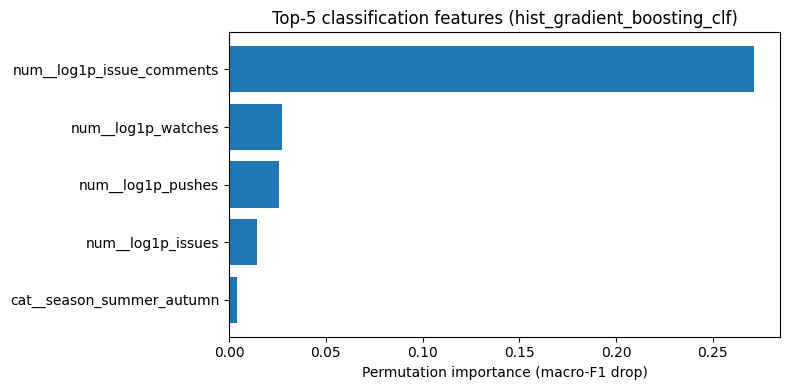

,feature,importance_mean,importance_std
0,num__log1p_issue_comments,0.052944,0.000559
1,num__log1p_watches,0.038604,0.000692
2,num__log1p_pushes,0.012446,0.000208
3,num__log1p_issues,0.008275,0.000144
4,num__activity_strength,0.003346,0.000101


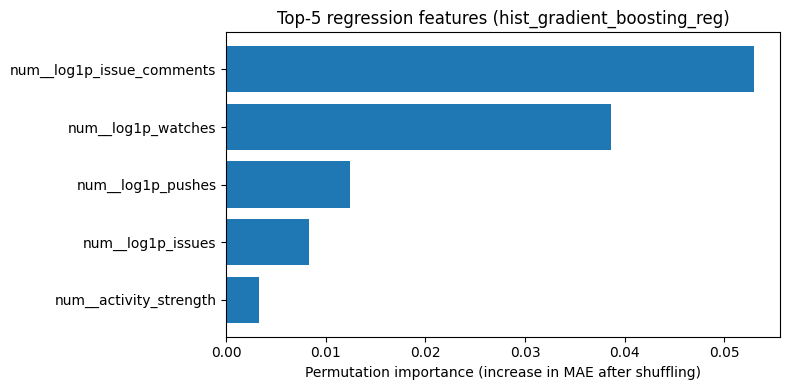

,example,repo_name,season,observation_window_days,has_conversion,fork_conversion_rate,rank_position,predicted_conversion_probability
11435,top_ranked,supabase/supabase,summer_autumn,30,1,0.081241,1,0.993584
71896,bottom_ranked,scarceassault/go-get-offer,winter_spring,30,0,0.000000,20000,0.019599


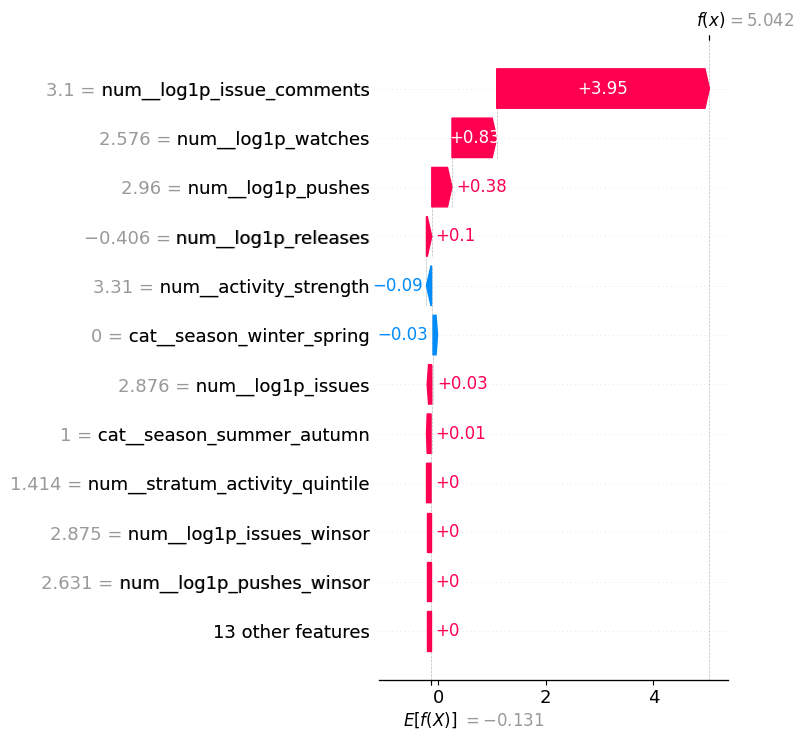

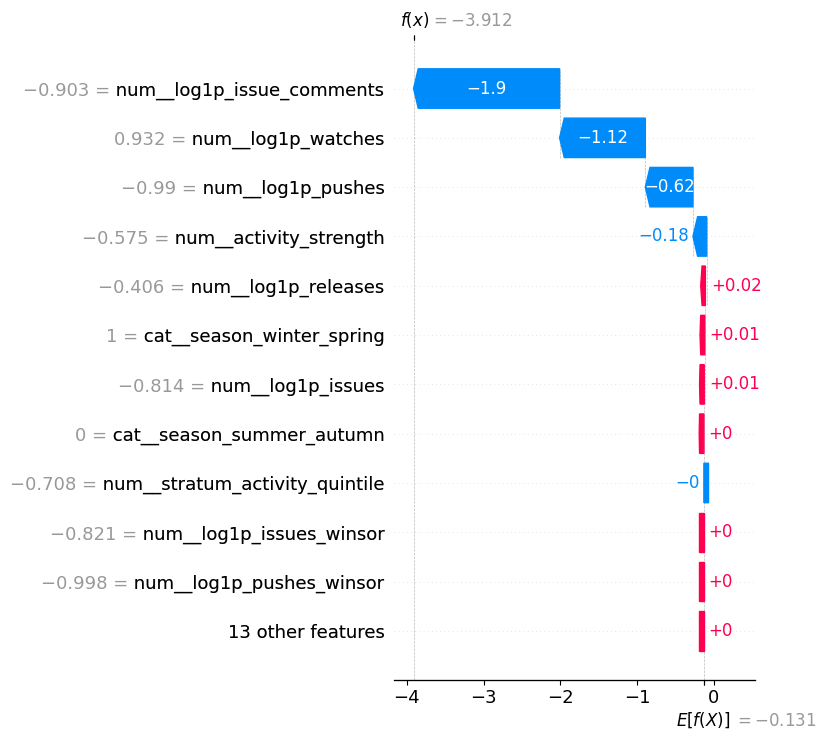

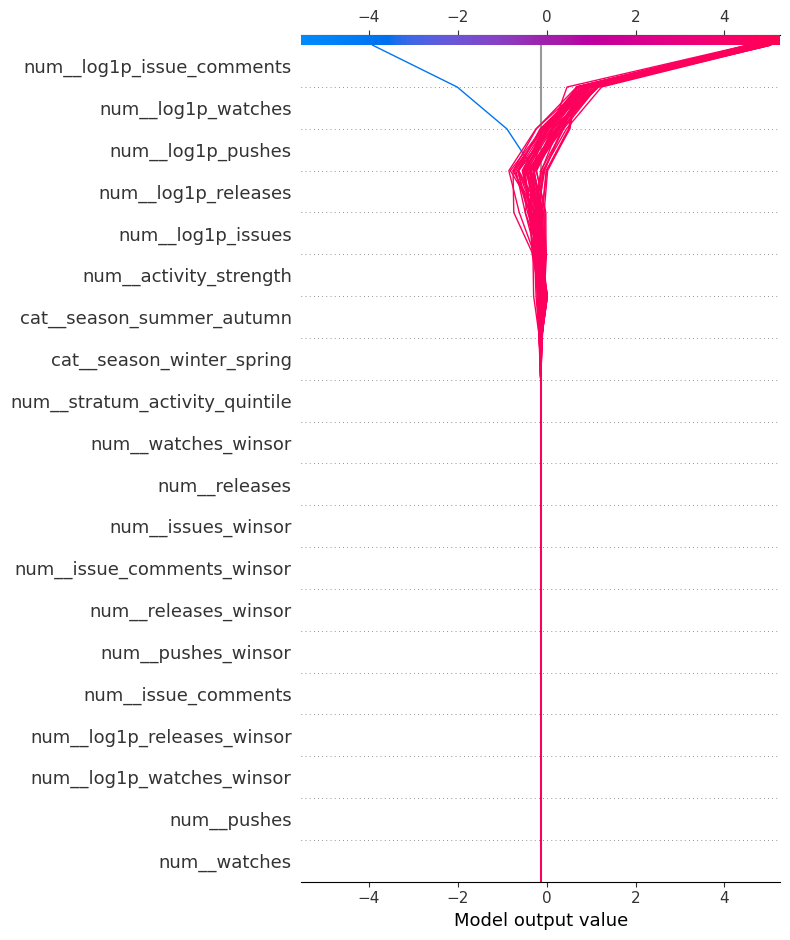

In [10]:
def _as_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


def _model_importance_df(model, feature_names):
    if hasattr(model, "feature_importances_"):
        values = model.feature_importances_
        label = "feature_importance"
    elif hasattr(model, "coef_"):
        values = np.ravel(np.abs(model.coef_))
        label = "abs_coefficient"
    else:
        return None
    return pd.DataFrame({"feature": feature_names, label: values}).sort_values(label, ascending=False)


if best_cls_name != "baseline_majority":
    best_cls_model.fit(X_train, y_cls_train)
    cls_prep = best_cls_model.named_steps["prep"]
    cls_model = best_cls_model.named_steps["model"]
    X_test_trans = cls_prep.transform(X_test)
    X_test_trans_dense = _as_dense(X_test_trans)
    feat_names = cls_prep.get_feature_names_out()

    cls_perm = permutation_importance(
        cls_model,
        X_test_trans,
        y_cls_test.values,
        n_repeats=8,
        random_state=42,
        scoring="f1_macro",
        n_jobs=-1,
    )
    cls_perm_importance = pd.DataFrame({
        "feature": feat_names,
        "importance_mean": cls_perm.importances_mean,
        "importance_std": cls_perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    top5_cls = cls_perm_importance.head(5).reset_index(drop=True)
    top5 = top5_cls
    display(top5_cls)

    plt.figure(figsize=(8, 4))
    plt.barh(top5_cls["feature"][::-1], top5_cls["importance_mean"][::-1])
    plt.xlabel("Permutation importance (macro-F1 drop)")
    plt.title(f"Top-5 classification features ({best_cls_name})")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "modeling_top5_features.png", dpi=150)
    plt.show()

    cls_model_importance = _model_importance_df(cls_model, feat_names)
    if cls_model_importance is not None:
        display(cls_model_importance.head(10).reset_index(drop=True))
else:
    print("Classification interpretability skipped: baseline model selected.")

if best_reg_name != "baseline_mean":
    best_reg_model.fit(X_train, y_reg_train)
    reg_prep = best_reg_model.named_steps["prep"]
    reg_model = best_reg_model.named_steps["model"]
    X_test_reg_trans = reg_prep.transform(X_test)
    reg_feat_names = reg_prep.get_feature_names_out()

    reg_perm = permutation_importance(
        reg_model,
        X_test_reg_trans,
        y_reg_test.values,
        n_repeats=8,
        random_state=42,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    reg_perm_importance = pd.DataFrame({
        "feature": reg_feat_names,
        "importance_mean": reg_perm.importances_mean,
        "importance_std": reg_perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    top5_reg = reg_perm_importance.head(5).reset_index(drop=True)
    display(top5_reg)

    plt.figure(figsize=(8, 4))
    plt.barh(top5_reg["feature"][::-1], top5_reg["importance_mean"][::-1])
    plt.xlabel("Permutation importance (increase in MAE after shuffling)")
    plt.title(f"Top-5 regression features ({best_reg_name})")
    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "modeling_top5_regression_features.png", dpi=150)
    plt.show()

    reg_model_importance = _model_importance_df(reg_model, reg_feat_names)
    if reg_model_importance is not None:
        display(reg_model_importance.head(10).reset_index(drop=True))
else:
    print("Regression interpretability skipped: baseline model selected.")

if best_cls_name != "baseline_majority" and hasattr(best_cls_model.named_steps["model"], "predict_proba"):
    p_test_for_examples = best_cls_model.predict_proba(X_test)[:, 1]
    ranked_positions = np.argsort(p_test_for_examples)[::-1]
    example_positions = [ranked_positions[0], ranked_positions[-1]]
    example_labels = ["top_ranked", "bottom_ranked"]

    example_cols = [c for c in ["repo_name", "season", "observation_window_days", "has_conversion", "fork_conversion_rate"] if c in df.columns]
    ranked_examples = df.loc[X_test.index[example_positions], example_cols].copy()
    ranked_examples.insert(0, "example", example_labels)
    ranked_examples["rank_position"] = [1, len(p_test_for_examples)]
    ranked_examples["predicted_conversion_probability"] = p_test_for_examples[example_positions]
    display(ranked_examples)

    try:
        import shap

        def _positive_class_shap(values):
            if isinstance(values, list):
                return values[1] if len(values) > 1 else values[0]
            arr = np.asarray(values)
            if arr.ndim == 3:
                return arr[:, :, 1] if arr.shape[2] > 1 else arr[:, :, 0]
            return arr

        def _positive_class_base(value):
            arr = np.asarray(value)
            if arr.ndim > 0 and arr.size > 1:
                return arr.ravel()[1]
            return float(arr.ravel()[0])

        shap_sample_positions = list(dict.fromkeys(list(example_positions) + list(ranked_positions[:50])))
        shap_X = X_test_trans_dense[shap_sample_positions]
        shap_explainer = shap.TreeExplainer(cls_model)
        shap_values = _positive_class_shap(shap_explainer.shap_values(shap_X))
        shap_base_value = _positive_class_base(shap_explainer.expected_value)

        for label, position in zip(example_labels, example_positions):
            local_idx = shap_sample_positions.index(position)
            explanation = shap.Explanation(
                values=shap_values[local_idx],
                base_values=shap_base_value,
                data=shap_X[local_idx],
                feature_names=feat_names,
            )
            shap.plots.waterfall(explanation, max_display=12, show=False)
            plt.tight_layout()
            plt.savefig(ARTIFACT_DIR / f"modeling_shap_waterfall_{label}.png", dpi=150, bbox_inches="tight")
            plt.show()

        shap.decision_plot(
            shap_base_value,
            shap_values,
            features=pd.DataFrame(shap_X, columns=feat_names),
            feature_names=list(feat_names),
            show=False,
        )
        plt.tight_layout()
        plt.savefig(ARTIFACT_DIR / "modeling_shap_decision_top_bottom_context.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"SHAP plots skipped: {exc}")

## 9) Sensitivity Check: 30d vs 90d Label Windows

Both prepared modeling files are evaluated with the same selected features and ranking metrics. 

In [11]:
def evaluate_window_dataset(frame, window):
    X_w, y_cls_w, y_reg_w, _, cat_cols_w, num_cols_w = make_xy(frame)
    X_train_w, X_test_w, y_cls_train_w, y_cls_test_w, y_reg_train_w, y_reg_test_w = train_test_split(
        X_w, y_cls_w, y_reg_w, test_size=0.2, random_state=42, stratify=y_cls_w
    )
    preprocess_w = make_preprocess(num_cols_w, cat_cols_w)
    clf_models_w, reg_models_w = make_model_specs(preprocess_w)

    # Use compact untuned candidates for window sensitivity so both files are comparable and fast enough.
    cls_table_w, reg_table_w = evaluate_models(
        X_train_w,
        X_test_w,
        y_cls_train_w,
        y_cls_test_w,
        y_reg_train_w,
        y_reg_test_w,
        clf_models_w,
        reg_models_w,
    )
    best_cls_w = cls_table_w.iloc[0]["model"]
    best_reg_w = reg_table_w.iloc[0]["model"]
    out = {
        "window_days": window,
        "rows": len(frame),
        "positive_rate": float(y_cls_w.mean()),
        "best_classifier": best_cls_w,
        "macro_f1": float(cls_table_w.iloc[0]["macro_f1"]),
        "roc_auc": float(cls_table_w.iloc[0]["roc_auc"]),
        "precision_at_10pct": float(cls_table_w.iloc[0]["precision_at_10pct"]),
        "best_regressor": best_reg_w,
        "mae": float(reg_table_w.iloc[0]["mae"]),
        "r2": float(reg_table_w.iloc[0]["r2"]),
    }
    return out


window_eval_rows = []
for window, frame in datasets_by_window.items():
    window_eval_rows.append(evaluate_window_dataset(frame.copy(), window))

window_sensitivity_table = pd.DataFrame(window_eval_rows).sort_values("window_days")
display(window_sensitivity_table)

if {30, 90}.issubset(datasets_by_window):
    key = ["repo_name", "season"]
    cmp = (
        datasets_by_window[30][key + ["n_forks", "n_converted_forks", "fork_conversion_rate"]]
        .rename(columns={"n_forks": "n_forks_30", "n_converted_forks": "nc_30", "fork_conversion_rate": "rate_30d"})
        .merge(
            datasets_by_window[90][key + ["n_forks", "n_converted_forks", "fork_conversion_rate"]]
            .rename(columns={"n_forks": "n_forks_90", "n_converted_forks": "nc_90", "fork_conversion_rate": "rate_90d"}),
            on=key,
            how="inner",
            validate="one_to_one",
        )
    )
    mask = (cmp["n_forks_30"] > 0) & (cmp["n_forks_90"] > 0)
    sub = cmp.loc[mask, ["rate_30d", "rate_90d"]].astype(float)
    rho = sub["rate_30d"].corr(sub["rate_90d"], method="spearman")
    tau = sub["rate_30d"].corr(sub["rate_90d"], method="kendall")
    p30 = sub["rate_30d"].rank(pct=True, method="average")
    p90 = sub["rate_90d"].rank(pct=True, method="average")
    strong_reversal = ((p30 >= 0.9) & (p90 <= 0.1)) | ((p30 <= 0.1) & (p90 >= 0.9))
    extra_conv = (cmp.loc[mask, "nc_90"].astype(int) - cmp.loc[mask, "nc_30"].astype(int)).clip(lower=0)
    tot90 = int(cmp.loc[mask, "nc_90"].astype(int).sum())

    label_window_rank_sensitivity = pd.DataFrame([
        {"metric": "rows_with_forks_in_both_windows", "value": int(mask.sum())},
        {"metric": "spearman_rate_rank_30d_vs_90d", "value": float(rho)},
        {"metric": "kendall_rate_rank_30d_vs_90d", "value": float(tau)},
        {"metric": "top_bottom_decile_reversals", "value": int(strong_reversal.sum())},
        {"metric": "extra_31_90d_conversion_share", "value": float(extra_conv.sum() / tot90) if tot90 > 0 else np.nan},
        {"metric": "median_rate_90d_minus_30d", "value": float((sub["rate_90d"] - sub["rate_30d"]).median())},
    ])
    display(label_window_rank_sensitivity)

,window_days,rows,positive_rate,best_classifier,macro_f1,roc_auc,precision_at_10pct,best_regressor,mae,r2
0,30,100000,0.47242,hist_gradient_boosting_clf,0.785039,0.861124,0.9475,hist_gradient_boosting_reg,0.101106,0.433337
1,90,100000,0.47914,hist_gradient_boosting_clf,0.777005,0.859582,0.9610,hist_gradient_boosting_reg,0.102408,0.450729


,metric,value
0,rows_with_forks_in_both_windows,100000.000000
1,spearman_rate_rank_30d_vs_90d,0.990972
2,kendall_rate_rank_30d_vs_90d,0.980456
3,top_bottom_decile_reversals,0.000000
4,extra_31_90d_conversion_share,0.035771
5,median_rate_90d_minus_30d,0.000000


## 10) Final Success-Criteria Digest

In [12]:
success_digest = {
    "main_window_days": MAIN_OBSERVATION_WINDOW_DAYS,
    "features_used": candidate_features,
    "classification": {
        "best_model": best_cls_name,
        "macro_f1": float(cls_table.iloc[0]["macro_f1"]),
        "macro_f1_gain_vs_baseline": float(cls_table.iloc[0]["macro_f1"] - cls_table.loc[cls_table["model"] == "baseline_majority", "macro_f1"].iloc[0]),
        "precision_at_10pct": float(cls_table.iloc[0]["precision_at_10pct"]),
    },
    "regression": {
        "best_model": best_reg_name,
        "mae": float(reg_table.iloc[0]["mae"]),
        "mae_better_than_baseline": bool(reg_table.iloc[0]["mae"] < reg_table.loc[reg_table["model"] == "baseline_mean", "mae"].iloc[0]),
        "r2": float(reg_table.iloc[0]["r2"]),
    },
    "ranking_quality": {
        "precision_at_10pct": float(precision_at_10) if "precision_at_10" in locals() else np.nan,
        "lift_at_10pct": float(lift_at_10) if "lift_at_10" in locals() else np.nan,
        "ndcg_at_10pct": float(ndcg_10) if "ndcg_10" in locals() else np.nan,
    },
    "sensitivity_check": {
        "windows_evaluated": list(window_sensitivity_table["window_days"]) if "window_sensitivity_table" in locals() else [],
    },
    "feature_interpretability": {
        "classification_top5_available": "top5_cls" in locals(),
        "regression_top5_available": "top5_reg" in locals(),
    },
}

print("=" * 72)
print("MODELING SUCCESS DIGEST")
print("=" * 72)
print(f"Main label window: {success_digest['main_window_days']}d")
print(f"Features used ({len(success_digest['features_used'])}): {', '.join(success_digest['features_used'])}")

cls = success_digest["classification"]
print("\n[Classification]")
print(f"  Best model: {cls['best_model']}")
print(f"  Macro-F1: {cls['macro_f1']:.4f}")
print(f"  Macro-F1 gain vs baseline: {cls['macro_f1_gain_vs_baseline']:.4f}")
print(f"  Precision@10%: {cls['precision_at_10pct']:.4f}")

reg = success_digest["regression"]
print("\n[Regression]")
print(f"  Best model: {reg['best_model']}")
print(f"  MAE: {reg['mae']:.4f}")
print(f"  MAE better than baseline: {reg['mae_better_than_baseline']}")
print(f"  R2: {reg['r2']:.4f}")

rk = success_digest["ranking_quality"]
print("\n[Ranking]")
print(f"  Precision@10%: {rk['precision_at_10pct']:.4f}" if not np.isnan(rk['precision_at_10pct']) else "  Precision@10%: NaN")
print(f"  Lift@10%: {rk['lift_at_10pct']:.4f}" if not np.isnan(rk['lift_at_10pct']) else "  Lift@10%: NaN")
print(f"  NDCG@10%: {rk['ndcg_at_10pct']:.4f}" if not np.isnan(rk['ndcg_at_10pct']) else "  NDCG@10%: NaN")

sens = success_digest["sensitivity_check"]
print("\n[Sensitivity]")
print(f"  Windows evaluated: {sens['windows_evaluated']}")

interp = success_digest["feature_interpretability"]
print("\n[Interpretability]")
print(f"  Classification top-5 available: {interp['classification_top5_available']}")
print(f"  Regression top-5 available: {interp['regression_top5_available']}")

print("=" * 72)

success_digest

MODELING SUCCESS DIGEST
Main label window: 30d
Features used (23): season, activity_strength, stratum_activity_quintile, log1p_issue_comments, log1p_issue_comments_winsor, log1p_issues, log1p_issues_winsor, log1p_pushes, log1p_pushes_winsor, log1p_releases, log1p_releases_winsor, log1p_watches, log1p_watches_winsor, watches, pushes, issues, issue_comments, releases, watches_winsor, pushes_winsor, issues_winsor, issue_comments_winsor, releases_winsor

[Classification]
  Best model: hist_gradient_boosting_clf
  Macro-F1: 0.7850
  Macro-F1 gain vs baseline: 0.4397
  Precision@10%: 0.9475

[Regression]
  Best model: hist_gradient_boosting_reg
  MAE: 0.1011
  MAE better than baseline: True
  R2: 0.4333

[Ranking]
  Precision@10%: 0.9475
  Lift@10%: 2.0057
  NDCG@10%: 0.9519

[Sensitivity]
  Windows evaluated: [30, 90]

[Interpretability]
  Classification top-5 available: True
  Regression top-5 available: True


{'main_window_days': 30,
 'features_used': ['season',
  'activity_strength',
  'stratum_activity_quintile',
  'log1p_issue_comments',
  'log1p_issue_comments_winsor',
  'log1p_issues',
  'log1p_issues_winsor',
  'log1p_pushes',
  'log1p_pushes_winsor',
  'log1p_releases',
  'log1p_releases_winsor',
  'log1p_watches',
  'log1p_watches_winsor',
  'watches',
  'pushes',
  'issues',
  'issue_comments',
  'releases',
  'watches_winsor',
  'pushes_winsor',
  'issues_winsor',
  'issue_comments_winsor',
  'releases_winsor'],
 'classification': {'best_model': 'hist_gradient_boosting_clf',
  'macro_f1': 0.7850392329421447,
  'macro_f1_gain_vs_baseline': 0.4396608616407569,
  'precision_at_10pct': 0.9475},
 'regression': {'best_model': 'hist_gradient_boosting_reg',
  'mae': 0.1011056283203821,
  'mae_better_than_baseline': True,
  'r2': 0.43333666258906767},
 'ranking_quality': {'precision_at_10pct': 0.9475,
  'lift_at_10pct': 2.0057154953429297,
  'ndcg_at_10pct': 0.9519491533775803},
 'sensitiv